# Analyst-Forecast-Based Equity Duration (FcstD)

Weighted-average maturity of projected earnings-based dividends. Uses
EPS analyst forecasts (h=1..3), linear ROE reversion to industry median
ROE (Gebhardt et al. 2001, h=4..10), steady-state projection (h=11..20),
and a common discount rate r = 0.12.

## 0. Setup

In [121]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from plot_style import COLORS, set_global_plot_style, style_axes, save_figure as _ps_save_figure

set_global_plot_style()

from project_paths import BASE_DIR, DATA_DIR, GRAPH_DIR

def save_parquet(df: pd.DataFrame, name: str):
    path = DATA_DIR / f"{name}.parquet"
    df.to_parquet(path, index=False)
    print(f"Saved: {path}")

def load_parquet(name: str) -> pd.DataFrame:
    path = DATA_DIR / f"{name}.parquet"
    return pd.read_parquet(path)

NOTEBOOK_GRAPH_DIR = GRAPH_DIR / "EQDuration_AnalystBased"
NOTEBOOK_GRAPH_DIR.mkdir(parents=True, exist_ok=True)

def save_figure(fig, name: str):
    path = NOTEBOOK_GRAPH_DIR / f"{name}.png"
    _ps_save_figure(fig, path, dpi=220)
    print(f"Saved figure: {path}")

## 1. Load data

In [122]:
raw = load_parquet("euro500_analystbased")
print(f"Loaded euro500_analystbased: {raw.shape[0]:,} rows, {raw.shape[1]} cols")
print(f"Firms: {raw['firm_id'].nunique():,}  |  Date range: {raw['date'].min()} – {raw['date'].max()}")

# Discount rate panel for Jensen corrections
np_out = load_parquet("EQDuration_Netpayout")
print(f"\nLoaded EQDuration_Netpayout: {np_out.shape[0]:,} rows")

Loaded euro500_analystbased: 13,500 rows, 23 cols
Firms: 1,094  |  Date range: 1998-12-31 00:00:00 – 2024-12-31 00:00:00

Loaded EQDuration_Netpayout: 12,073 rows


## 2. Sample restrictions

In [123]:
df = raw.copy()
df["year"] = df["date"].dt.year

n0 = len(df)
funnel = [("Raw input", n0)]

# 1) Year >= 1998
df = df[df["year"] >= 1998].copy()
funnel.append(("year >= 1998", len(df)))

# 2) Exclude Financials (RIM duration not meaningful for banks/insurers)
df = df[df["trbc_sector"] != "Financials"].copy()
funnel.append(("Exclude Financials", len(df)))

# 3) NumAnalysts >= 3
df = df[df["NumAnalysts_fy1"] >= 3].copy()
funnel.append(("NumAnalysts_fy1 >= 3", len(df)))

# 4) EPS_fy1 not NaN
df = df[df["EPS_fy1_est"].notna()].copy()
funnel.append(("EPS_fy1_est not NaN", len(df)))

# 5) Positive BE, ME, shares
df = df[(df["BE"] > 0) & (df["ME"] > 0) & (df["shares_outstanding"] > 0)].copy()
funnel.append(("BE > 0 & ME > 0 & shares > 0", len(df)))

# 6) Negative FY2/FY3 exclusion (S&E Appendix A)
neg_fy = ((df["EPS_fy2_est"] * df["shares_outstanding"]) < 0) | \
         ((df["EPS_fy3_est"] * df["shares_outstanding"]) < 0)
df = df[~neg_fy.fillna(False)].copy()
funnel.append(("FY2/FY3 not negative", len(df)))

print(f"Final sample: {len(df):,} firm-years, "
      f"{df['firm_id'].nunique():,} unique firms\n")
funnel_df = pd.DataFrame(funnel, columns=["Step", "Firm-years"])
funnel_df["Dropped"] = -funnel_df["Firm-years"].diff(-1).fillna(0).astype(int)
print(funnel_df.to_string(index=False))

Final sample: 9,390 firm-years, 737 unique firms

                        Step  Firm-years  Dropped
                   Raw input       13500        0
                year >= 1998       13500    -2001
          Exclude Financials       11499    -1702
        NumAnalysts_fy1 >= 3        9797       -2
         EPS_fy1_est not NaN        9795     -237
BE > 0 & ME > 0 & shares > 0        9558     -168
        FY2/FY3 not negative        9390        0


## 3. Industry ROE

In [124]:
# ROE proxy from FY1 analyst forecast
df["ROE_current"] = (df["EPS_fy1_est"] * df["shares_outstanding"]) / df["BE"]

# Winsorize ROE at 1st/99th before computing industry medians
q01 = df["ROE_current"].quantile(0.01)
q99 = df["ROE_current"].quantile(0.99)
roe_for_ind = df[["firm_id", "year", "trbc_sector", "ROE_current"]].copy()
roe_for_ind["ROE_current"] = roe_for_ind["ROE_current"].clip(q01, q99)

# Trailing 5-year median by sector
industry_roe = {}
for year in sorted(df["year"].unique()):
    window = roe_for_ind[
        (roe_for_ind["year"] >= year - 4) & (roe_for_ind["year"] <= year)
    ]
    meds = window.groupby("trbc_sector")["ROE_current"].median()
    for sector, med in meds.items():
        med = max(med, 0.005)       # floor at 0.5%
        med = min(med, 0.50)        # cap at 50%
        industry_roe[(sector, year)] = med

df["industry_roe"] = df.apply(
    lambda row: industry_roe.get((row["trbc_sector"], row["year"]), np.nan),
    axis=1,
)

# Fallback: cross-sectional median for that year
year_meds = df.groupby("year")["industry_roe"].transform("median")
df["industry_roe"] = df["industry_roe"].fillna(year_meds)

print(f"Industry ROE coverage: {df['industry_roe'].notna().sum()} / {len(df)}")
print("\nIndustry ROE by sector:")
print(df.groupby("trbc_sector")["industry_roe"].agg(["mean", "median"])
      .round(3).to_string())

Industry ROE coverage: 9390 / 9390

Industry ROE by sector:
                                             mean  median
trbc_sector                                              
Basic Materials                             0.105   0.107
Consumer Cyclicals                          0.139   0.144
Consumer Non-Cyclicals                      0.131   0.128
Energy                                      0.138   0.133
Healthcare                                  0.129   0.124
Industrials                                 0.124   0.128
Institutions, Associations & Organizations  0.500   0.500
Real Estate                                 0.068   0.070
Technology                                  0.160   0.151
Utilities                                   0.096   0.098


## 4. Duration construction

Weighted-average maturity (WAM) of projected earnings-based dividends,
following the three-stage earnings model of Gebhardt et al. (2001):

- **Stage 1 (h=1..3):** EPS analyst forecasts (I/B/E/S)
- **Stage 2 (h=4..10):** Linear ROE reversion to industry median ROE
- **Stage 3 (h=11..20):** Steady state at industry ROE

All cash flows discounted at a common r = 0.12 (Dechow et al. 2004).
Terminal value TV = max(ME - PV, 0) assigned to h = 20.

In [125]:
H_EXPLICIT = 3       # analyst forecast horizon
H_TRANSITION = 7     # ROE reversion h=4..10
H_CONVERGED = 10     # steady state h=11..20
H_TOTAL = 20         # total explicit horizon
R_COMMON = 0.12      # common discount rate
ROE_CAP = 1.0        # cap extreme ROE


def compute_fcstd(row):
    """
    Weighted-average maturity of projected earnings-based dividends.
    """
    BE_t = float(row["BE"])
    ME   = float(row["ME"])
    shares = float(row["shares_outstanding"])
    roe_target = float(row["industry_roe"])

    nan_return = {
        "ROE_fy1": np.nan, "ROE_fy2": np.nan, "ROE_fy3": np.nan,
        "b_fy1": np.nan, "b_fy2": np.nan, "b_fy3": np.nan,
        "industry_roe_used": np.nan,
        "PV_forecast": np.nan, "TV": np.nan,
        "pv_fit_poor": True,
        "Duration_FcstD_raw": np.nan,
    }

    if pd.isna(roe_target):
        return nan_return

    # ── Analyst inputs ──────────────────────────────────────
    eps = [row["EPS_fy1_est"], row["EPS_fy2_est"], row["EPS_fy3_est"]]
    dps = [row["DPS_fy1_est"], row["DPS_fy2_est"], row["DPS_fy3_est"]]
    ltg = row.get("LTG_est", np.nan)

    E = [c * shares if pd.notna(c) else np.nan for c in eps]

    # FY3 fallback via LTG
    if pd.isna(E[2]) and pd.notna(E[1]) and pd.notna(ltg):
        E[2] = E[1] * (1.0 + ltg)

    # ── Payout ratio: fade from current to 50% ─────────────
    if pd.notna(dps[0]) and pd.notna(E[0]) and E[0] > 0:
        p_current = np.clip((dps[0] * shares) / E[0], 0.0, 1.0)
    else:
        p_current = 0.5

    def payout_at(h):
        fade = min(h / 10.0, 1.0)  # reaches 50% at h=10
        return p_current + (0.5 - p_current) * fade

    # ── Sequential forward pass ─────────────────────────────
    ROE_path, B_start, b_payout = [], [], []
    BE_prev = BE_t

    # Stage 1: Explicit (h=1..3)
    for h in range(1, 4):
        B_start.append(BE_prev)
        h_idx = h - 1
        roe_h = np.clip(E[h_idx] / BE_prev, -ROE_CAP, ROE_CAP) \
                if (pd.notna(E[h_idx]) and BE_prev > 0) else np.nan
        ROE_path.append(roe_h)
        p_h = payout_at(h)
        b_payout.append(p_h)
        if pd.notna(E[h_idx]):
            BE_prev = BE_prev + E[h_idx] * (1.0 - p_h)
            BE_prev = max(BE_prev, 0.01)

    # Stage 2: Transition (h=4..10)
    ROE_last = next((ROE_path[i] for i in range(2, -1, -1)
                     if pd.notna(ROE_path[i])), roe_target)
    for h in range(4, 11):
        B_start.append(BE_prev)
        alpha = (h - 3) / 7.0
        roe_h = ROE_last * (1 - alpha) + roe_target * alpha
        ROE_path.append(roe_h)
        p_h = payout_at(h)
        b_payout.append(p_h)
        BE_prev = BE_prev + roe_h * BE_prev * (1 - p_h)
        BE_prev = max(BE_prev, 0.01)

    # Stage 3: Steady state (h=11..20)
    for h in range(11, 21):
        B_start.append(BE_prev)
        ROE_path.append(roe_target)
        b_payout.append(0.5)
        BE_prev = BE_prev + roe_target * BE_prev * 0.5
        BE_prev = max(BE_prev, 0.01)

    # ── Cash flows and WAM duration ─────────────────────────
    r = R_COMMON
    PV_total = 0.0
    WAM_num = 0.0

    for h_idx in range(H_TOTAL):
        h = h_idx + 1
        roe_h = ROE_path[h_idx]
        if pd.isna(roe_h) or B_start[h_idx] <= 0:
            continue
        cf_h = roe_h * B_start[h_idx] * b_payout[h_idx]
        pv_h = cf_h / (1.0 + r) ** h
        PV_total += pv_h
        WAM_num += h * pv_h

    TV = max(ME - PV_total, 0.0)
    pv_fit_poor = PV_total > ME
    WAM_num += H_TOTAL * TV
    Duration_raw = WAM_num / ME if ME > 0 else np.nan

    return {
        "ROE_fy1": ROE_path[0], "ROE_fy2": ROE_path[1], "ROE_fy3": ROE_path[2],
        "b_fy1": b_payout[0], "b_fy2": b_payout[1], "b_fy3": b_payout[2],
        "industry_roe_used": roe_target,
        "PV_forecast": PV_total, "TV": TV,
        "pv_fit_poor": pv_fit_poor,
        "Duration_FcstD_raw": Duration_raw,
    }


# ── Apply ───────────────────────────────────────────────────
print(f"Computing FcstD for {len(df):,} firm-years ...")
results = df.apply(compute_fcstd, axis=1, result_type="expand")
df = pd.concat([df, results], axis=1)
print("Done.")

valid = df["Duration_FcstD_raw"].notna()
print(f"\nValid: {valid.sum():,} / {len(df):,} ({valid.mean():.1%})")
print(f"pv_fit_poor (PV > ME): {df['pv_fit_poor'].sum():,}")
dur = df.loc[valid, "Duration_FcstD_raw"]
print(f"\nDuration -- mean: {dur.mean():.1f}, median: {dur.median():.1f}, "
      f"std: {dur.std():.2f}")
print(f"PV/ME -- mean: {(df.loc[valid, 'PV_forecast']/df.loc[valid, 'ME']).mean():.1%}")
print(f"TV share -- mean: {(df.loc[valid, 'TV']/df.loc[valid, 'ME']).mean():.1%}")

Computing FcstD for 9,390 firm-years ...
Done.

Valid: 9,390 / 9,390 (100.0%)
pv_fit_poor (PV > ME): 439

Duration -- mean: 19.7, median: 16.1, std: 108.96
PV/ME -- mean: 84.6%
TV share -- mean: 58.5%


## 5. Winsorization

In [126]:
# P1/P99 winsorization (global)
valid = df["Duration_FcstD_raw"].notna()
p1 = df.loc[valid, "Duration_FcstD_raw"].quantile(0.01)
p99 = df.loc[valid, "Duration_FcstD_raw"].quantile(0.99)

df["Duration_FcstD"] = df["Duration_FcstD_raw"].clip(lower=p1, upper=p99)
df.loc[~valid, "Duration_FcstD"] = np.nan
df["pv_fit_poor"] = df["Duration_FcstD"].isna()

print(f"Winsorization: P1={p1:.2f}, P99={p99:.2f}")
usable = ~df["pv_fit_poor"]
dur_w = df.loc[usable, "Duration_FcstD"]
print(f"Valid: {usable.sum():,} / {len(df):,} ({usable.mean():.1%})")
print(f"Mean: {dur_w.mean():.2f}, Median: {dur_w.median():.2f}, "
      f"Std: {dur_w.std():.2f}")

Winsorization: P1=9.64, P99=34.00
Valid: 9,390 / 9,390 (100.0%)
Mean: 15.99, Median: 16.09, Std: 2.81


## 6. Save output

In [127]:
out_cols = [
    "firm_id", "date", "year", "trbc_sector",
    "EPS_fy1_est", "EPS_fy2_est", "EPS_fy3_est",
    "DPS_fy1_est", "DPS_fy2_est", "DPS_fy3_est",
    "NumAnalysts_fy1", "shares_outstanding", "BE", "ME",
    "ROE_fy1", "ROE_fy2", "ROE_fy3",
    "b_fy1", "b_fy2", "b_fy3",
    "industry_roe_used",
    "PV_forecast", "TV", "pv_fit_poor",
    "Duration_FcstD_raw", "Duration_FcstD",
]

out = df[out_cols].copy().sort_values(["firm_id", "date"]).reset_index(drop=True)
save_parquet(out, "EQDuration_Fcst")
print(f"Saved: {out.shape[0]:,} rows, {out.shape[1]} cols")
print(f"Unique firms: {out['firm_id'].nunique():,}")

Saved: /Users/jakob/Documents/Parforceleistung/Studium/MSc Economics/Masterarbeit/Project_Data/intermediate/EQDuration_Fcst.parquet
Saved: 9,390 rows, 26 cols
Unique firms: 737


## 7. Diagnostics

Cross-sectional variation, Spearman correlations, and comparison
with Net-Payout Duration.

In [128]:
# Cross-sectional variation: σ comparison by year
_np = load_parquet("EQDuration_Netpayout")[["firm_id", "date", "Duration_NetPayout"]]
_merged = df.merge(_np, on=["firm_id", "date"], how="left")

print("Cross-sectional σ by year:")
print("-" * 60)
for label, col in [("FcstD", "Duration_FcstD"), ("NpD", "Duration_NetPayout")]:
    if col in _merged.columns:
        ys = _merged.groupby("year")[col].std()
        print(f"  {label:20s}  avg σ = {ys.mean():.3f}")

Cross-sectional σ by year:
------------------------------------------------------------
  FcstD                 avg σ = 2.685
  NpD                   avg σ = 3.915


In [129]:
# Spearman rank correlations
from scipy.stats import spearmanr

_np = load_parquet("EQDuration_Netpayout")[["firm_id", "date", "Duration_NetPayout"]]
corr_panel = df.merge(_np, on=["firm_id", "date"], how="left")
corr_panel["EP"] = corr_panel["ROE_fy1"]
corr_panel["BM"] = corr_panel["BE"] / corr_panel["ME"]

diag = corr_panel[["Duration_FcstD", "Duration_NetPayout", "EP", "BM"]].dropna()

print(f"Spearman correlations (n={len(diag):,}):")
print("-" * 60)

corr_vars = {"FcstD": "Duration_FcstD", "NpD": "Duration_NetPayout",
             "E/P": "EP", "B/M": "BM"}
labels = list(corr_vars.keys())
cols = list(corr_vars.values())
sub = diag[cols].dropna()
rho_matrix = np.full((len(cols), len(cols)), np.nan)
for i in range(len(cols)):
    for j in range(i, len(cols)):
        r, _ = spearmanr(sub[cols[i]], sub[cols[j]])
        rho_matrix[i, j] = r
        rho_matrix[j, i] = r

rho_df = pd.DataFrame(rho_matrix, index=labels, columns=labels)
print(rho_df.to_string(float_format=lambda x: f"{x:.3f}"))

print("\nKey correlations:")
print(f"  ρ(FcstD, B/M) = {rho_matrix[0, 3]:+.3f}")
print(f"  ρ(FcstD, E/P) = {rho_matrix[0, 2]:+.3f}")
print(f"  ρ(FcstD, NpD) = {rho_matrix[0, 1]:+.3f}")

Spearman correlations (n=7,834):
------------------------------------------------------------
       FcstD    NpD    E/P    B/M
FcstD  1.000  0.309  0.006 -0.607
NpD    0.309  1.000  0.022 -0.283
E/P    0.006  0.022  1.000 -0.552
B/M   -0.607 -0.283 -0.552  1.000

Key correlations:
  ρ(FcstD, B/M) = -0.607
  ρ(FcstD, E/P) = +0.006
  ρ(FcstD, NpD) = +0.309


Saved figure: /Users/jakob/Documents/Parforceleistung/Studium/MSc Economics/Masterarbeit/Project_Data/graphs/EQDuration_AnalystBased/fcstd_diagnostics.png


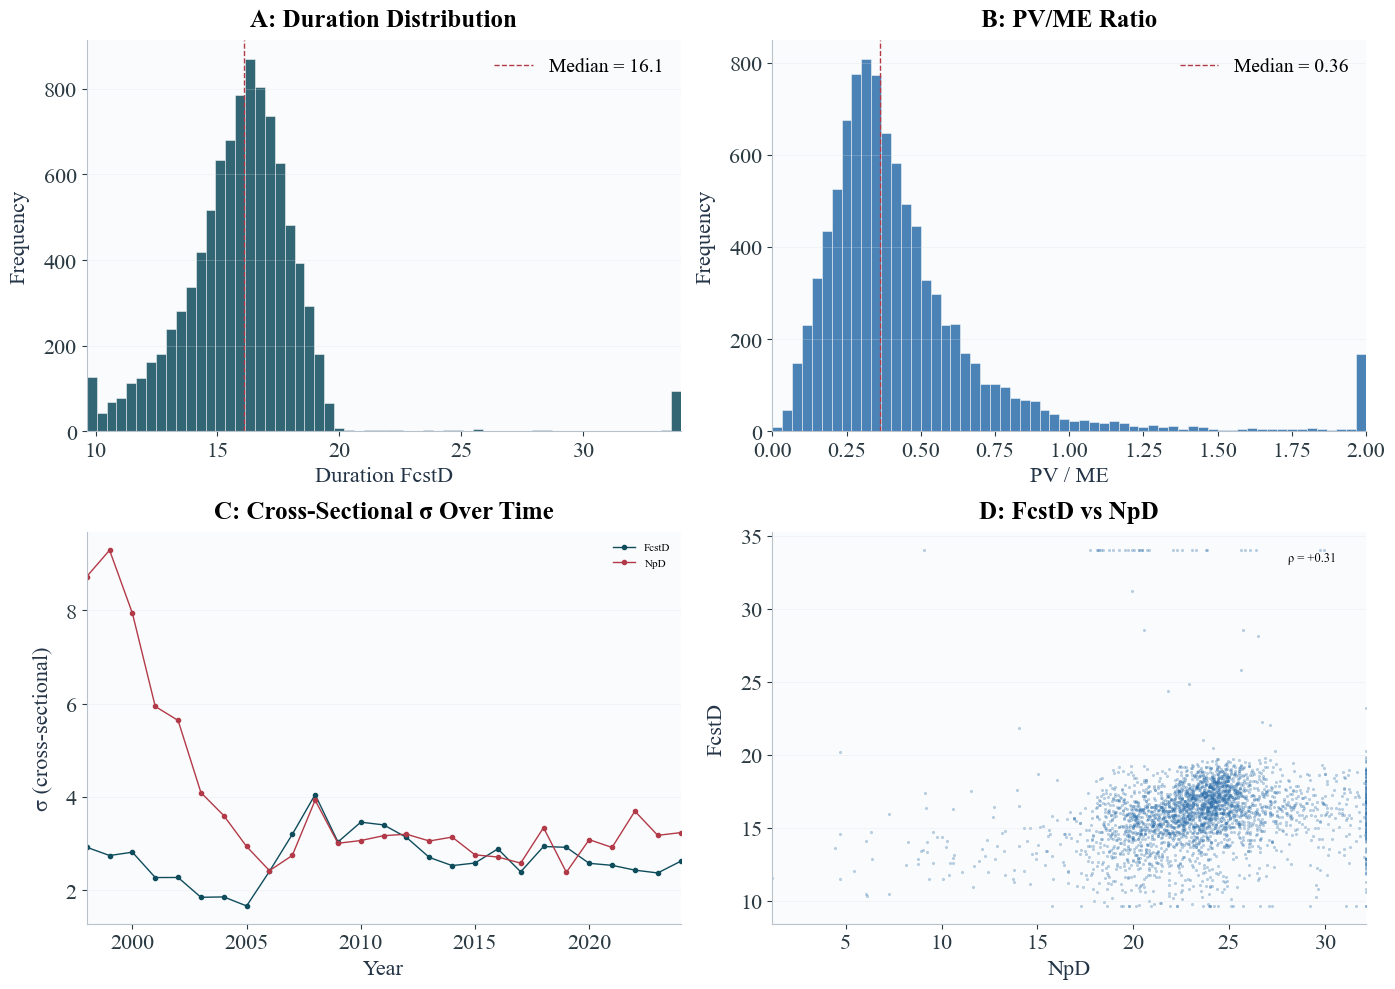

In [130]:
set_global_plot_style()

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# A: Duration distribution
fcstd_valid = df[df["Duration_FcstD"].notna()]
axes[0, 0].hist(fcstd_valid["Duration_FcstD"], bins=60,
                color=COLORS["primary"], edgecolor="white", alpha=0.85)
axes[0, 0].set_xlabel("Duration FcstD")
axes[0, 0].set_ylabel("Frequency")
axes[0, 0].set_title("A: Duration Distribution")
axes[0, 0].axvline(fcstd_valid["Duration_FcstD"].median(), color=COLORS["accent"],
                    ls="--", label=f'Median = {fcstd_valid["Duration_FcstD"].median():.1f}')
axes[0, 0].legend(frameon=False)
style_axes(axes[0, 0])

# B: PV/ME ratio
pv_me = df.loc[df["Duration_FcstD"].notna(), "PV_forecast"] / \
        df.loc[df["Duration_FcstD"].notna(), "ME"]
axes[0, 1].hist(pv_me.clip(0, 2), bins=60, color=COLORS["blue"],
                edgecolor="white", alpha=0.85)
axes[0, 1].set_xlabel("PV / ME")
axes[0, 1].set_ylabel("Frequency")
axes[0, 1].set_title("B: PV/ME Ratio")
axes[0, 1].axvline(pv_me.median(), color=COLORS["accent"], ls="--",
                    label=f'Median = {pv_me.median():.2f}')
axes[0, 1].legend(frameon=False)
style_axes(axes[0, 1])

# C: σ over time
_np = load_parquet("EQDuration_Netpayout")[["firm_id", "date", "Duration_NetPayout"]]
_mg = df.merge(_np, on=["firm_id", "date"], how="left")
for label, col, color in [
    ("FcstD", "Duration_FcstD", COLORS["primary"]),
    ("NpD", "Duration_NetPayout", COLORS["accent"]),
]:
    if col in _mg.columns:
        ys = _mg.groupby("year")[col].std()
        axes[1, 0].plot(ys.index, ys.values, marker="o", ms=3, label=label, color=color)
axes[1, 0].set_xlabel("Year")
axes[1, 0].set_ylabel("σ (cross-sectional)")
axes[1, 0].set_title("C: Cross-Sectional σ Over Time")
axes[1, 0].legend(frameon=False, fontsize=8)
style_axes(axes[1, 0])

# D: FcstD vs NpD scatter
_sc = _mg[_mg["Duration_FcstD"].notna() & _mg["Duration_NetPayout"].notna()]
if len(_sc) > 3000:
    _sc_plot = _sc.sample(3000, random_state=42)
else:
    _sc_plot = _sc
from scipy.stats import spearmanr as _sp
_rho, _ = _sp(_sc["Duration_FcstD"], _sc["Duration_NetPayout"])
axes[1, 1].scatter(_sc_plot["Duration_NetPayout"], _sc_plot["Duration_FcstD"],
                   s=3, alpha=0.3, color=COLORS["blue"])
axes[1, 1].set_xlabel("NpD")
axes[1, 1].set_ylabel("FcstD")
axes[1, 1].set_title("D: FcstD vs NpD")
axes[1, 1].text(0.95, 0.95, f"ρ = {_rho:+.2f}",
                transform=axes[1, 1].transAxes, ha="right", va="top", fontsize=9)
style_axes(axes[1, 1])

fig.tight_layout()
save_figure(fig, "fcstd_diagnostics")
plt.show()

In [131]:
# Summary
from scipy.stats import spearmanr

print("=" * 70)
print("FcstD Duration -- WAM, common r=0.12, H=20")
print("=" * 70)

# Industry ROE
print("\n1. Industry ROE (trailing 5-year median):")
print(df.groupby("trbc_sector")["industry_roe_used"].agg(["mean", "median"])
      .to_string(float_format=lambda x: f"{x:.3f}"))

# Sample
valid = df["Duration_FcstD"].notna()
n_valid = valid.sum()
print(f"\n2. Sample: {n_valid:,} / {len(df):,} ({n_valid/len(df):.1%})")
print(f"   pv_fit_poor: {df['pv_fit_poor'].sum():,}")

# Duration stats
_np = load_parquet("EQDuration_Netpayout")[["firm_id", "date", "Duration_NetPayout"]]
_mg = df.merge(_np, on=["firm_id", "date"], how="left")
_sub = _mg[_mg["Duration_FcstD"].notna()].copy()
dur = _sub["Duration_FcstD"]
print(f"\n3. Duration:")
print(f"   Mean: {dur.mean():.2f}, Median: {dur.median():.2f}, Std: {dur.std():.2f}")
print(f"   P5: {dur.quantile(0.05):.2f}, P95: {dur.quantile(0.95):.2f}")

_both = _sub.dropna(subset=["Duration_NetPayout"])
if len(_both) > 50:
    rho_np, _ = spearmanr(_both["Duration_FcstD"], _both["Duration_NetPayout"])
    print(f"   ρ(FcstD, NpD) = {rho_np:+.3f} (n={len(_both):,})")
_sub_ep = _sub.dropna(subset=["ROE_fy1"])
if len(_sub_ep) > 50:
    rho_ep, _ = spearmanr(_sub_ep["Duration_FcstD"], _sub_ep["ROE_fy1"])
    print(f"   ρ(FcstD, E/P) = {rho_ep:+.3f}")
_sub["BM"] = _sub["BE"] / _sub["ME"]
rho_bm, _ = spearmanr(_sub["Duration_FcstD"], _sub["BM"])
print(f"   ρ(FcstD, B/M) = {rho_bm:+.3f}")

# PV/ME
pv_me = df.loc[valid, "PV_forecast"] / df.loc[valid, "ME"]
tv_share = df.loc[valid, "TV"] / df.loc[valid, "ME"]
print(f"\n4. PV/ME: mean={pv_me.mean():.1%}, median={pv_me.median():.1%}")
print(f"   TV share: mean={tv_share.mean():.1%}, median={tv_share.median():.1%}")
print("=" * 70)

FcstD Duration -- WAM, common r=0.12, H=20

1. Industry ROE (trailing 5-year median):
                                            mean  median
trbc_sector                                             
Basic Materials                            0.105   0.107
Consumer Cyclicals                         0.139   0.144
Consumer Non-Cyclicals                     0.131   0.128
Energy                                     0.138   0.133
Healthcare                                 0.129   0.124
Industrials                                0.124   0.128
Institutions, Associations & Organizations 0.500   0.500
Real Estate                                0.068   0.070
Technology                                 0.160   0.151
Utilities                                  0.096   0.098

2. Sample: 9,390 / 9,390 (100.0%)
   pv_fit_poor: 0

3. Duration:
   Mean: 15.99, Median: 16.09, Std: 2.81
   P5: 11.79, P95: 18.86
   ρ(FcstD, NpD) = +0.309 (n=7,834)
   ρ(FcstD, E/P) = -0.009
   ρ(FcstD, B/M) = -0.595

4. PV/ME

## 8. Distribution Diagnostics

### 8.1 Sample Funnel

In [132]:
print("Sample Funnel:")
print(funnel_df.to_string(index=False))

Sample Funnel:
                        Step  Firm-years  Dropped
                   Raw input       13500        0
                year >= 1998       13500    -2001
          Exclude Financials       11499    -1702
        NumAnalysts_fy1 >= 3        9797       -2
         EPS_fy1_est not NaN        9795     -237
BE > 0 & ME > 0 & shares > 0        9558     -168
        FY2/FY3 not negative        9390        0


### 8.2 Duration Distribution

Saved figure: /Users/jakob/Documents/Parforceleistung/Studium/MSc Economics/Masterarbeit/Project_Data/graphs/EQDuration_AnalystBased/duration_fcstd_distribution.png


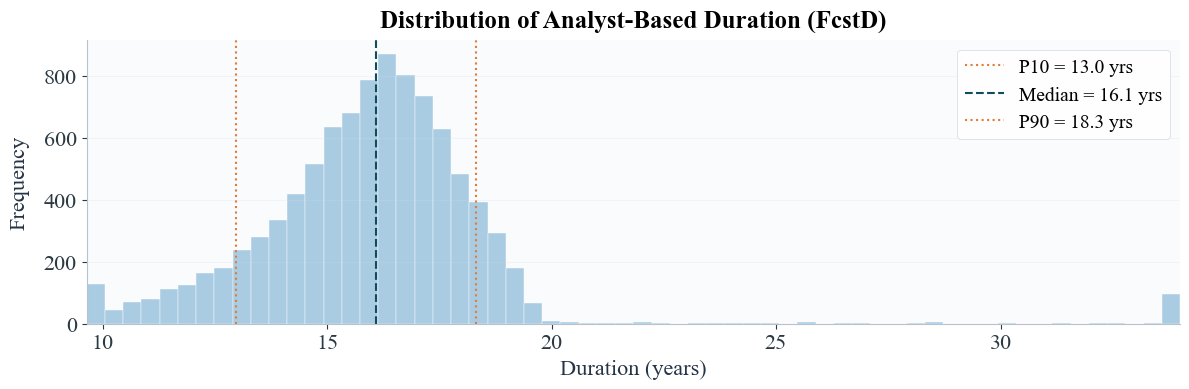

In [133]:
set_global_plot_style()

dur_plot = out.loc[out["Duration_FcstD"].notna(), "Duration_FcstD"].dropna()

fig, ax = plt.subplots(figsize=(12, 4))
ax.hist(dur_plot, bins=60, color=COLORS["blue_light"],
        edgecolor="white", linewidth=0.3, density=False)

_p10 = dur_plot.quantile(0.10)
_p50 = dur_plot.quantile(0.50)
_p90 = dur_plot.quantile(0.90)

ax.axvline(_p10, color=COLORS.get("coral", "#e07b39"),
           lw=1.5, ls=":",
           label=f"P10 = {_p10:.1f} yrs")
ax.axvline(_p50, color=COLORS.get("primary", "#1f4e79"),
           lw=1.5, ls="--",
           label=f"Median = {_p50:.1f} yrs")
ax.axvline(_p90, color=COLORS.get("coral", "#e07b39"),
           lw=1.5, ls=":",
           label=f"P90 = {_p90:.1f} yrs")

ax.set_title("Distribution of Analyst-Based Duration (FcstD)")
ax.set_xlabel("Duration (years)")
ax.set_ylabel("Frequency")
ax.legend(frameon=True)
style_axes(ax)
plt.tight_layout()
save_figure(fig, "duration_fcstd_distribution")
plt.show()

### 8.3 Duration Over Time

Saved figure: /Users/jakob/Documents/Parforceleistung/Studium/MSc Economics/Masterarbeit/Project_Data/graphs/EQDuration_AnalystBased/duration_fcstd_over_time.png


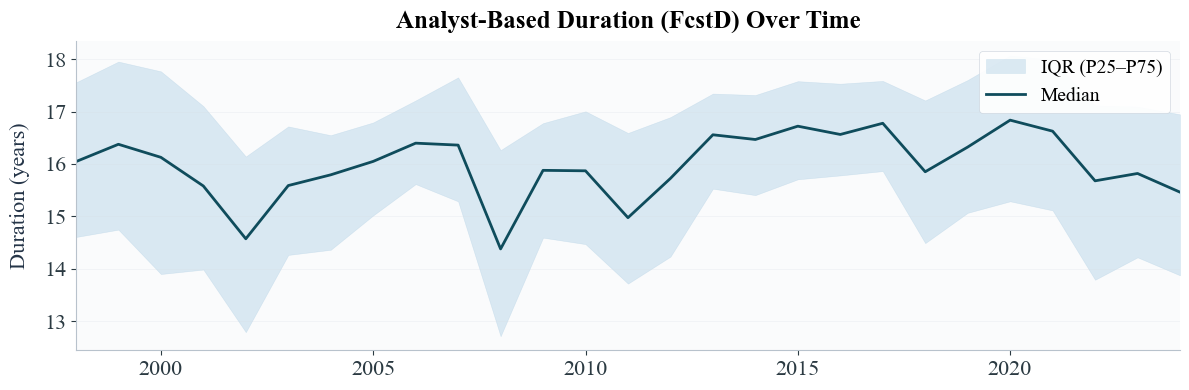

In [134]:
set_global_plot_style()

usable = out.loc[out["Duration_FcstD"].notna()].copy()
usable["year"] = usable["date"].dt.year

time_stats = usable.groupby("year")["Duration_FcstD"].agg(
    median="median", q25=lambda x: x.quantile(0.25), q75=lambda x: x.quantile(0.75)
).reset_index()

fig, ax = plt.subplots(figsize=(12, 4))
ax.fill_between(time_stats["year"], time_stats["q25"], time_stats["q75"],
                color=COLORS["blue_light"], alpha=0.4, label="IQR (P25–P75)")
ax.plot(time_stats["year"], time_stats["median"],
        color=COLORS["primary"], lw=2.0, label="Median")

ax.set_title("Analyst-Based Duration (FcstD) Over Time")
ax.set_xlabel("")
ax.set_ylabel("Duration (years)")
ax.set_xlim(1998, usable["year"].max())
style_axes(ax)
ax.legend(loc="upper right", frameon=True, facecolor=(1,1,1,0.82),
          edgecolor="#C4CDD7", framealpha=0.92)
plt.tight_layout()
save_figure(fig, "duration_fcstd_over_time")
plt.show()

### 8.4 Decile Analysis

Duration deciles vs payout yield to verify that high-duration firms
have low near-term payouts (growth firms).

In [146]:
dec = usable.copy()
dec["payout_yield"] = (
    dec["DPS_fy1_est"] * dec["shares_outstanding"] / dec["ME"]
)

dec["dur_decile"] = dec.groupby("year")["Duration_FcstD"].transform(
    lambda x: pd.qcut(x, 10, labels=range(1, 11), duplicates="drop")
)
dec["dur_decile"] = pd.to_numeric(dec["dur_decile"], errors="coerce")

decile_table = (
    dec.groupby("dur_decile")
    .agg(
        median_duration=("Duration_FcstD", "median"),
        median_payout_yield=("payout_yield", "median"),
        n_obs=("Duration_FcstD", "count"),
    )
    .reset_index()
)
decile_table["median_payout_yield"] = decile_table["median_payout_yield"] * 100  # percent

print("Decile Analysis: Duration vs Payout Yield")
print(decile_table.to_string(index=False, float_format="{:.2f}".format))

Decile Analysis: Duration vs Payout Yield
 dur_decile  median_duration  median_payout_yield  n_obs
          1            11.96                 5.45    953
          2            13.81                 4.20    937
          3            14.67                 3.66    934
          4            15.24                 3.21    939
          5            15.79                 2.76    939
          6            16.26                 2.36    932
          7            16.78                 1.94    937
          8            17.24                 1.52    936
          9            17.84                 0.92    935
         10            18.85                 0.49    948


### 8.5 Correlation with Net-Payout Duration and Fundamentals

In [136]:
# Inspect columns before merge
print("out columns:", list(out.columns))
print("np_out Duration-like columns:", [c for c in np_out.columns if "uration" in c or "dur" in c.lower()])

# Merge with NetPayout duration
np_dur = np_out[["firm_id", "year", "Duration_NetPayout"]].copy()
np_dur = np_dur.rename(columns={"Duration_NetPayout": "Duration_NP"})

corr_df = out.copy()
corr_df["year"] = corr_df["date"].dt.year
corr_df = corr_df.merge(np_dur, on=["firm_id", "year"], how="left")

# Merge diagnostics
n_np_matched = corr_df["Duration_NP"].notna().sum()
n_total = len(corr_df)
print(f"\nMerge diagnostics:")
print(f"  Rows with non-null Duration_NP: {n_np_matched:,} / {n_total:,} ({n_np_matched/n_total:.1%})")

corr_usable_all = corr_df.loc[corr_df["Duration_FcstD"].notna()].copy()
n_usable_np = corr_usable_all["Duration_NP"].notna().sum()
n_usable = len(corr_usable_all)
print(f"  Usable FcstD sample with matched NP: {n_usable_np:,} / {n_usable:,} ({n_usable_np/n_usable:.1%})")

if n_usable_np / n_usable < 0.50:
    print(f"\n  ⚠ Coverage warning: Only {n_usable_np/n_usable:.1%} of usable FcstD firm-years")
    print(f"    have a matched NP duration. This is likely due to different sample periods")
    print(f"    or filter differences between the analyst-based and net-payout notebooks.")

# Construct additional variables
corr_df["BM"] = corr_df["BE"] / corr_df["ME"]
corr_df["EP"] = (corr_df["EPS_fy1_est"] * corr_df["shares_outstanding"]) / corr_df["ME"]
corr_df["log_ME"] = np.log(corr_df["ME"])

# Filter usable
corr_usable = corr_df.loc[corr_df["Duration_FcstD"].notna()].copy()

corr_vars = ["Duration_FcstD", "Duration_NP", "log_ME", "BM", "EP"]

# Pearson
corr_matrix = corr_usable[corr_vars].corr()
print("\nPearson Correlation Matrix (usable sample):")
print(corr_matrix.to_string(float_format="{:.3f}".format))

# Spearman
spearman = corr_usable[corr_vars].corr(method="spearman")
print("\nSpearman Rank Correlation:")
print(spearman.to_string(float_format="{:.3f}".format))

# Focal correlations
both_valid = corr_usable[["Duration_FcstD", "Duration_NP"]].dropna()
print(f"\nFocal: Corr(FcstD, NP) on {len(both_valid):,} overlapping firm-years:")
print(f"  Pearson:  {both_valid['Duration_FcstD'].corr(both_valid['Duration_NP']):.3f}")
print(f"  Spearman: {both_valid['Duration_FcstD'].corr(both_valid['Duration_NP'], method='spearman'):.3f}")

out columns: ['firm_id', 'date', 'year', 'trbc_sector', 'EPS_fy1_est', 'EPS_fy2_est', 'EPS_fy3_est', 'DPS_fy1_est', 'DPS_fy2_est', 'DPS_fy3_est', 'NumAnalysts_fy1', 'shares_outstanding', 'BE', 'ME', 'ROE_fy1', 'ROE_fy2', 'ROE_fy3', 'b_fy1', 'b_fy2', 'b_fy3', 'industry_roe_used', 'PV_forecast', 'TV', 'pv_fit_poor', 'Duration_FcstD_raw', 'Duration_FcstD']
np_out Duration-like columns: ['Duration_NetPayout', 'Duration_NP_strict', 'duration_usable', 'duration_usable_strict']

Merge diagnostics:
  Rows with non-null Duration_NP: 8,665 / 9,390 (92.3%)
  Usable FcstD sample with matched NP: 8,665 / 9,390 (92.3%)

Pearson Correlation Matrix (usable sample):
                Duration_FcstD  Duration_NP  log_ME     BM     EP
Duration_FcstD           1.000        0.190   0.093 -0.274  0.095
Duration_NP              0.190        1.000   0.163 -0.175 -0.039
log_ME                   0.093        0.163   1.000 -0.162  0.003
BM                      -0.274       -0.175  -0.162  1.000 -0.015
EP          

Saved figure: /Users/jakob/Documents/Parforceleistung/Studium/MSc Economics/Masterarbeit/Project_Data/graphs/EQDuration_AnalystBased/coverage_fcstd_annual.png


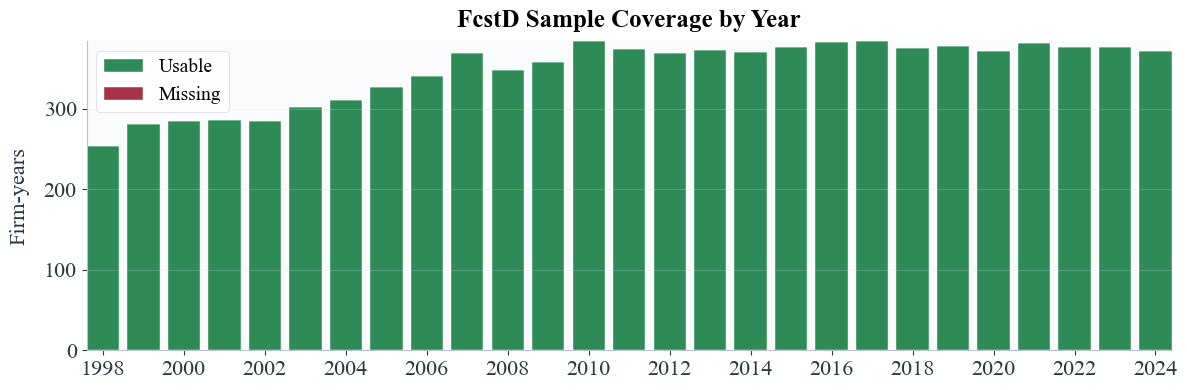

In [137]:
set_global_plot_style()

# Coverage by year
_cov = out.copy()
_cov["year"] = _cov["date"].dt.year
_cov_grp = (
    _cov.groupby("year")
    .agg(
        usable=("Duration_FcstD", lambda s: int(s.notna().sum())),
        missing=("Duration_FcstD", lambda s: int(s.isna().sum())),
    )
    .reset_index()
)
_cov_grp = _cov_grp[(_cov_grp["year"] >= 1998) & (_cov_grp["year"] <= 2024)]

fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(_cov_grp["year"], _cov_grp["usable"],
       color=COLORS["green"], edgecolor="white", linewidth=0.3,
       label="Usable")
ax.bar(_cov_grp["year"], _cov_grp["missing"],
       bottom=_cov_grp["usable"],
       color=COLORS["red"], edgecolor="white", linewidth=0.3,
       label="Missing")

ax.set_title("FcstD Sample Coverage by Year")
ax.set_xlabel("")
ax.set_ylabel("Firm-years")
ax.set_xticks(range(1998, 2025, 2))
style_axes(ax)
ax.legend(loc="upper left", frameon=True, facecolor=(1, 1, 1, 0.82),
          edgecolor="#C4CDD7", framealpha=0.92)
plt.tight_layout()
save_figure(fig, "coverage_fcstd_annual")
plt.show()

Saved figure: /Users/jakob/Documents/Parforceleistung/Studium/MSc Economics/Masterarbeit/Project_Data/graphs/EQDuration_AnalystBased/fcstd_decile_payout_yield.png


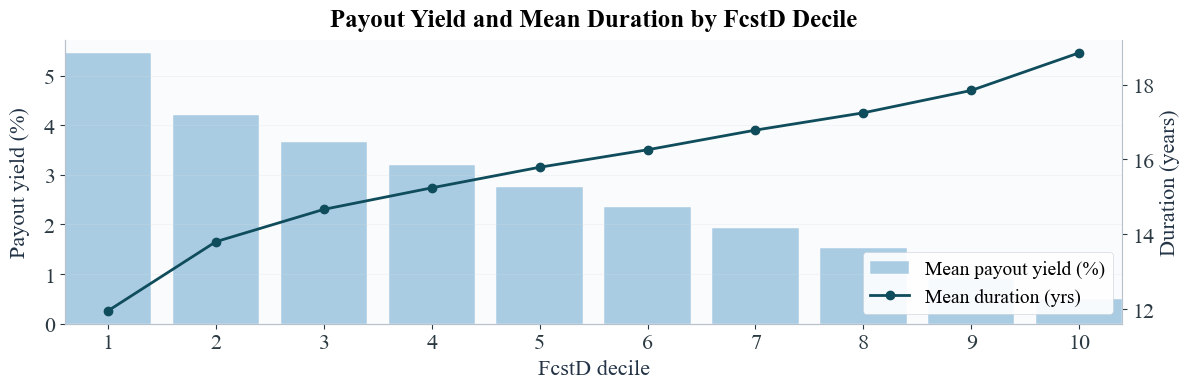

In [147]:
set_global_plot_style()

# Use existing `dec` DataFrame from Cell 22 decile analysis
_dec_plot = (
    dec.dropna(subset=["dur_decile"])
    .groupby("dur_decile")
    .agg(
        mean_duration=("Duration_FcstD", "median"),
        mean_payout_yield=("payout_yield", "median"),
    )
    .reset_index()
)
_dec_plot["mean_payout_yield_pct"] = _dec_plot["mean_payout_yield"] * 100

fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(_dec_plot["dur_decile"], _dec_plot["mean_payout_yield_pct"],
       color=COLORS["blue_light"], edgecolor="white", linewidth=0.3,
       label="Mean payout yield (%)")
ax.set_xlabel("FcstD decile")
ax.set_ylabel("Payout yield (%)")
ax.set_xticks(range(1, 11))
style_axes(ax)

ax2 = ax.twinx()
ax2.plot(_dec_plot["dur_decile"], _dec_plot["mean_duration"],
         color=COLORS["primary"], lw=2.0, marker="o",
         label="Mean duration (yrs)")
ax2.set_ylabel("Duration (years)")
ax2.spines["top"].set_visible(False)
ax2.spines["right"].set_color("#B8C2CC")
ax2.tick_params(axis="y", labelsize=16)

ax.set_title("Payout Yield and Mean Duration by FcstD Decile")

lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, loc="lower right",
          frameon=True, facecolor=(1, 1, 1, 0.82),
          edgecolor="#C4CDD7", framealpha=0.92)
plt.tight_layout()
save_figure(fig, "fcstd_decile_payout_yield")
plt.show()

Saved figure: /Users/jakob/Documents/Parforceleistung/Studium/MSc Economics/Masterarbeit/Project_Data/graphs/EQDuration_AnalystBased/fcstd_npd_scatter.png


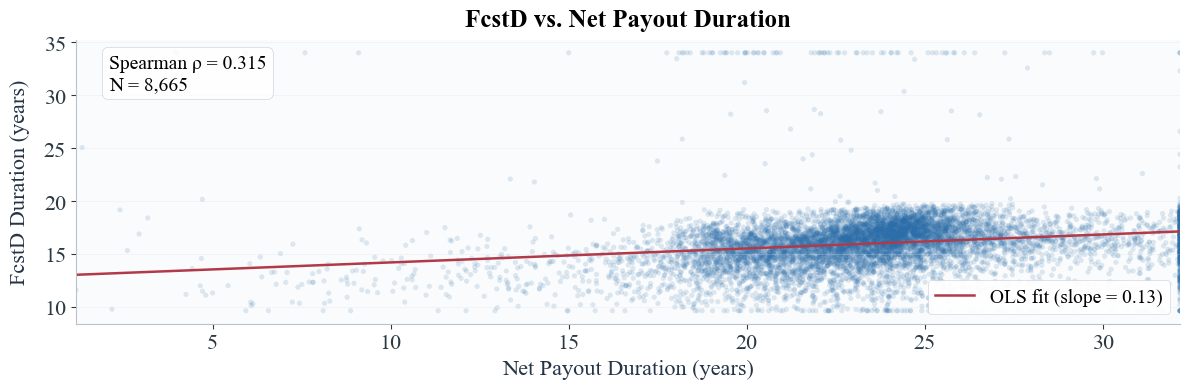

In [139]:
set_global_plot_style()

# Scatter FcstD vs NpD using corr_df from Cell 24
_sc = corr_df.loc[corr_df["Duration_FcstD"].notna(), ["Duration_FcstD", "Duration_NP"]].dropna()

_rho_s = _sc["Duration_FcstD"].corr(_sc["Duration_NP"], method="spearman")

# Linear regression line
_x = _sc["Duration_NP"].values
_y = _sc["Duration_FcstD"].values
_slope, _intercept = np.polyfit(_x, _y, 1)
_x_line = np.linspace(_x.min(), _x.max(), 100)
_y_line = _slope * _x_line + _intercept

fig, ax = plt.subplots(figsize=(12, 4))
ax.scatter(_sc["Duration_NP"], _sc["Duration_FcstD"],
           alpha=0.15, s=14, color=COLORS["blue"],
           edgecolors="none")
ax.plot(_x_line, _y_line, color=COLORS["accent"], lw=1.8,
        label=f"OLS fit (slope = {_slope:.2f})")

ax.text(0.03, 0.95,
        f"Spearman ρ = {_rho_s:.3f}\nN = {len(_sc):,}",
        transform=ax.transAxes, va="top", ha="left",
        fontsize=14,
        bbox=dict(boxstyle="round,pad=0.35",
                  facecolor=(1, 1, 1, 0.82),
                  edgecolor="#C4CDD7"))

ax.set_title("FcstD vs. Net Payout Duration")
ax.set_xlabel("Net Payout Duration (years)")
ax.set_ylabel("FcstD Duration (years)")
style_axes(ax)
ax.legend(loc="lower right", frameon=True, facecolor=(1, 1, 1, 0.82),
          edgecolor="#C4CDD7", framealpha=0.92)
plt.tight_layout()
save_figure(fig, "fcstd_npd_scatter")
plt.show()

Saved figure: /Users/jakob/Documents/Parforceleistung/Studium/MSc Economics/Masterarbeit/Project_Data/graphs/EQDuration_AnalystBased/roe_reversion_example.png


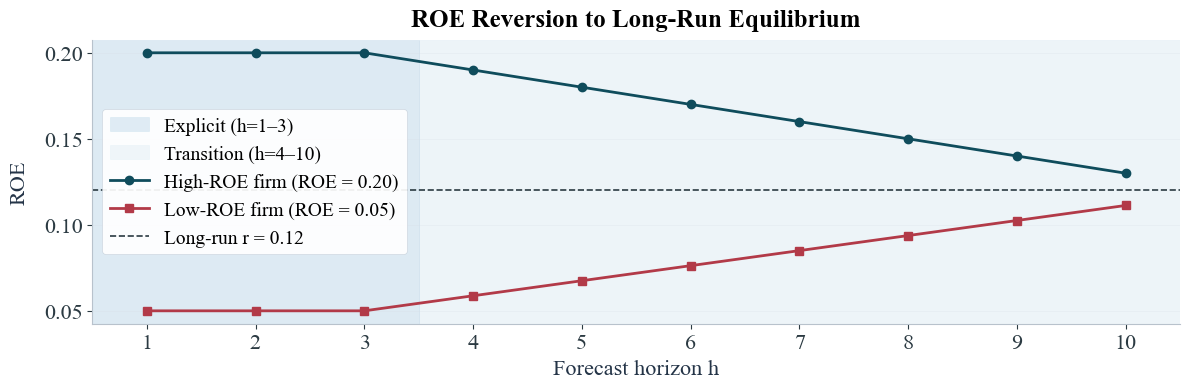

In [140]:
set_global_plot_style()

# Illustrative ROE reversion schematic
_r_bar = 0.12
_h = np.arange(1, 11)

def _roe_path(roe0: float) -> np.ndarray:
    path = np.empty_like(_h, dtype=float)
    for i, h in enumerate(_h):
        if h <= 3:
            path[i] = roe0
        else:
            alpha = (h - 3) / 8.0
            path[i] = (1 - alpha) * roe0 + alpha * _r_bar
    return path

_high = _roe_path(0.20)
_low = _roe_path(0.05)

fig, ax = plt.subplots(figsize=(12, 4))

# Shaded regions
ax.axvspan(0.5, 3.5, color=COLORS["blue_light"], alpha=0.35, label="Explicit (h=1–3)")
ax.axvspan(3.5, 10.5, color=COLORS["blue_light"], alpha=0.15, label="Transition (h=4–10)")

ax.plot(_h, _high, color=COLORS["primary"], lw=2.0, marker="o",
        label="High-ROE firm (ROE = 0.20)")
ax.plot(_h, _low, color=COLORS["accent"], lw=2.0, marker="s",
        label="Low-ROE firm (ROE = 0.05)")

ax.axhline(_r_bar, color=COLORS["reference"], lw=1.2, ls="--",
           label=f"Long-run r = {_r_bar:.2f}")

ax.set_title("ROE Reversion to Long-Run Equilibrium")
ax.set_xlabel("Forecast horizon h")
ax.set_ylabel("ROE")
ax.set_xticks(_h)
ax.set_xlim(0.5, 10.5)
style_axes(ax)
ax.legend(loc="center left", frameon=True, facecolor=(1, 1, 1, 0.82),
          edgecolor="#C4CDD7", framealpha=0.92)
plt.tight_layout()
save_figure(fig, "roe_reversion_example")
plt.show()

In [141]:
# GRAFIK-ÜBERSICHT: FcstD figures
_fcstd_figs = [
    "duration_fcstd_distribution",
    "duration_fcstd_over_time",
    "coverage_fcstd_annual",
    "tv_share_fcstd_hist",
    "fcstd_decile_payout_yield",
    "fcstd_npd_scatter",
    "roe_reversion_example",
]

print("GRAFIK-ÜBERSICHT – EQDuration_AnalystBased")
print(f"Directory: {NOTEBOOK_GRAPH_DIR}")
print("-" * 60)
for _name in _fcstd_figs:
    _p = NOTEBOOK_GRAPH_DIR / f"{_name}.png"
    _mark = "✓" if _p.exists() else "✗"
    print(f"  [{_mark}] {_name}.png")
print("-" * 60)
_n_ok = sum((NOTEBOOK_GRAPH_DIR / f"{n}.png").exists() for n in _fcstd_figs)
print(f"Total: {_n_ok}/{len(_fcstd_figs)} figures present")

GRAFIK-ÜBERSICHT – EQDuration_AnalystBased
Directory: /Users/jakob/Documents/Parforceleistung/Studium/MSc Economics/Masterarbeit/Project_Data/graphs/EQDuration_AnalystBased
------------------------------------------------------------
  [✓] duration_fcstd_distribution.png
  [✓] duration_fcstd_over_time.png
  [✓] coverage_fcstd_annual.png
  [✓] tv_share_fcstd_hist.png
  [✓] fcstd_decile_payout_yield.png
  [✓] fcstd_npd_scatter.png
  [✓] roe_reversion_example.png
------------------------------------------------------------
Total: 7/7 figures present


## 9. Summary Statistics

In [142]:
usable_final = out.loc[out["Duration_FcstD"].notna()].copy()
dur = usable_final["Duration_FcstD"].dropna()

print("=" * 50)
print("FINAL SUMMARY")
print("=" * 50)
print(f"Output shape:       {out.shape}")
print(f"Usable firm-years:  {len(usable_final):,} / {len(out):,} ({len(usable_final)/len(out):.1%})")
print(f"Missing rate:       {out['Duration_FcstD'].isna().mean():.1%}")
print(f"\nDuration_FcstD percentiles (usable sample):")
for p_val, label in [(0.10, "P10"), (0.25, "P25"), (0.50, "P50"), (0.75, "P75"), (0.90, "P90")]:
    print(f"  {label}: {dur.quantile(p_val):.2f}")
print(f"  Mean: {dur.mean():.2f}")
print(f"  Std:  {dur.std():.2f}")

FINAL SUMMARY
Output shape:       (9390, 26)
Usable firm-years:  9,390 / 9,390 (100.0%)
Missing rate:       0.0%

Duration_FcstD percentiles (usable sample):
  P10: 12.96
  P25: 14.65
  P50: 16.09
  P75: 17.25
  P90: 18.31
  Mean: 15.99
  Std:  2.81
